# Model A - Shared Encoder

차선, 정지선, 횡단보도 등 도로 구조 요소의 공통 시각 특징을 추출하는 Shared Encoder를 구성한다.

- Backbone: `ConvNeXt-Tiny`
- Segmentation Head와 Vector Head가 Encoder feature를 공유
- PyTorch 기반 구현
- Encoder 입력 이미지는 Quality Check를 통과한 **Final Manifest 8,788장**을 기준으로 사용


## 1. Environment Check

현재 Notebook이 프로젝트 가상환경과 CUDA 지원 PyTorch를 정상적으로 사용하고 있는지 확인한다.

Python / PyTorch 버전, 실행 중인 Python 경로, CUDA 사용 가능 여부와 GPU 이름을 확인한다.  

In [1]:
import sys
import torch

print("Python version :", sys.version.split()[0])
print("Python path    :", sys.executable)

print("PyTorch version:", torch.__version__)
print("CUDA build     :", torch.version.cuda)
print("CUDA available :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name       :", torch.cuda.get_device_name(0))

Python version : 3.11.9
Python path    : c:\accident_ai\Accident_AI\.venv\Scripts\python.exe
PyTorch version: 2.13.0+cu126
CUDA build     : 12.6
CUDA available : True
GPU name       : NVIDIA GeForce RTX 3060


## 2. Path Setup

원본 이미지 경로와 이전 Data Quality Check의 최종 출력 경로를 연결한다.  
Encoder / Vector 쪽에서는 Final Image Manifest와 Ordered Lane Vector를 사용하며, Segmentation annotation은 현재 노트북에서 불러오지 않는다.


In [2]:
from pathlib import Path


# ============================================================
# 전체 로컬 작업공간
# ============================================================

WORKSPACE_ROOT = Path(r"C:\accident_ai")


# ============================================================
# 원본 이미지
# ============================================================

IMAGE_ROOT = (
    WORKSPACE_ROOT
    / "lane_data"
    / "Training"
    / "image"
)


# ============================================================
# 이전 Data Quality Check Notebook의 최종 출력
# = Model A Encoder 입력
# ============================================================

ENCODER_INPUT_ROOT = (
    WORKSPACE_ROOT
    / "outputs"
    / "modelA_Data_Quality_check_outputs"
)


IMAGE_MANIFEST_PATH = (
    ENCODER_INPUT_ROOT
    / "modelA_image_manifest_final.jsonl"
)

LANE_VECTOR_ORDERED_PATH = (
    ENCODER_INPUT_ROOT
    / "modelA_lane_vector_ordered_final.jsonl"
)


# ============================================================
# 필수 경로 존재 여부 확인
# ============================================================

for path_name, path in {
    "IMAGE_ROOT": IMAGE_ROOT,
    "IMAGE_MANIFEST_PATH": IMAGE_MANIFEST_PATH,
    "LANE_VECTOR_ORDERED_PATH": LANE_VECTOR_ORDERED_PATH,
}.items():

    if not path.exists():
        raise FileNotFoundError(
            f"{path_name} 경로가 없습니다: {path}"
        )


print("IMAGE_ROOT:")
print(IMAGE_ROOT)

print()

print("ENCODER_INPUT_ROOT:")
print(ENCODER_INPUT_ROOT)

print()

print("IMAGE_MANIFEST_PATH:")
print(IMAGE_MANIFEST_PATH)

print()

print("LANE_VECTOR_ORDERED_PATH:")
print(LANE_VECTOR_ORDERED_PATH)

IMAGE_ROOT:
C:\accident_ai\lane_data\Training\image

ENCODER_INPUT_ROOT:
C:\accident_ai\outputs\modelA_Data_Quality_check_outputs

IMAGE_MANIFEST_PATH:
C:\accident_ai\outputs\modelA_Data_Quality_check_outputs\modelA_image_manifest_final.jsonl

LANE_VECTOR_ORDERED_PATH:
C:\accident_ai\outputs\modelA_Data_Quality_check_outputs\modelA_lane_vector_ordered_final.jsonl


## 3. Load Final Quality-Checked Data

이전 `modelA_Data_Quality_check.ipynb`에서 생성한 최종 데이터를 불러온다.

- `df_image_manifest`: Quality Check를 통과한 최종 **8,788장**의 이미지 기준 정보
- `df_lane_vector_ordered`: traffic lane이 존재하는 이미지의 최종 ordered lane vector 정보


In [3]:
import pandas as pd


# ============================================================
# Final Image Manifest Load
# ============================================================

df_image_manifest = pd.read_json(
    IMAGE_MANIFEST_PATH,
    lines=True
)


# ============================================================
# Final Ordered Lane Vector Load
# ============================================================

df_lane_vector_ordered = pd.read_json(
    LANE_VECTOR_ORDERED_PATH,
    lines=True
)


# ============================================================
# 기본 구조 확인
# ============================================================

print("Final Image Manifest shape:")
print(df_image_manifest.shape)

print(
    "Final Image Manifest 고유 이미지:",
    df_image_manifest["file_name"].nunique()
)

print()

print("Final Ordered Lane Vector shape:")
print(df_lane_vector_ordered.shape)

print(
    "Final Ordered Lane Vector 고유 이미지:",
    df_lane_vector_ordered["file_name"].nunique()
)

print()

print("[Final Image Manifest sample]")
display(df_image_manifest.head(10))

print()

print("[Final Ordered Lane Vector sample]")

display(df_lane_vector_ordered.head(10))

Final Image Manifest shape:
(8788, 11)
Final Image Manifest 고유 이미지: 8788

Final Ordered Lane Vector shape:
(46539, 14)
Final Ordered Lane Vector 고유 이미지: 8763

[Final Image Manifest sample]


,file_name,image_size,annotation_count,traffic_lane_count,stop_line_count,crosswalk_count,has_traffic_lane,has_stop_line,has_crosswalk,annotation_type,blackbox_id
0,13883084.jpg,"[1080, 1920]",8,8,0,0,True,False,False,lane,0
1,13883085.jpg,"[1080, 1920]",8,8,0,0,True,False,False,lane,0
2,13883471.jpg,"[1080, 1920]",8,8,0,0,True,False,False,lane,0
3,13883472.jpg,"[1080, 1920]",8,8,0,0,True,False,False,lane,0
4,13883473.jpg,"[1080, 1920]",8,8,0,0,True,False,False,lane,0
5,13883474.jpg,"[1080, 1920]",8,8,0,0,True,False,False,lane,0
6,13883475.jpg,"[1080, 1920]",8,8,0,0,True,False,False,lane,0
7,13883476.jpg,"[1080, 1920]",8,8,0,0,True,False,False,lane,0
8,13883477.jpg,"[1080, 1920]",8,8,0,0,True,False,False,lane,0
9,13883478.jpg,"[1080, 1920]",8,8,0,0,True,False,False,lane,0



[Final Ordered Lane Vector sample]


,file_name,image_size,lane_id,lane_order,lane_color,lane_type,category,x_data,y_data,point_count,lane_order_x,lane_order_y,lane_order_method,blackbox_id
0,13883084.jpg,"[1080, 1920]",0,0,white,solid,polyline,"[207, 206, 480, 832]","[724, 723, 663, 584]",4,604.759494,635,common_y,0
1,13883084.jpg,"[1080, 1920]",1,1,white,dotted,polyline,"[909, 809]","[591, 651]",2,835.666667,635,common_y,0
2,13883084.jpg,"[1080, 1920]",7,2,white,solid,polyline,"[1022, 1145, 1263]","[589, 684, 778]",3,1081.557895,635,common_y,0
3,13883084.jpg,"[1080, 1920]",6,3,white,solid,polyline,"[1021, 1129, 1311]","[582, 653, 772]",3,1101.619718,635,common_y,0
4,13883084.jpg,"[1080, 1920]",5,4,white,solid,polyline,"[1678, 1274, 1035]","[739, 630, 568]",3,1292.532110,635,common_y,0
5,13883084.jpg,"[1080, 1920]",4,5,white,solid,polyline,"[1031, 1270, 1560, 1709]","[565, 623, 696, 731]",4,1317.671233,635,common_y,0
6,13883084.jpg,"[1080, 1920]",2,6,white,dotted,polyline,"[1162, 1561]","[578, 635]",2,1561.000000,635,common_y,0
7,13883084.jpg,"[1080, 1920]",3,7,white,solid,polyline,"[1194, 1547, 1853, 1908]","[571, 607, 640, 649]",4,1806.636364,635,common_y,0
8,13883085.jpg,"[1080, 1920]",0,0,white,solid,polyline,"[265, 499, 842]","[716, 658, 584]",3,531.445946,651,common_y,0
9,13883085.jpg,"[1080, 1920]",1,1,white,dotted,polyline,"[905, 703]","[600, 723]",2,821.243902,651,common_y,0


## 4. Encoder Input Image Check

Final Image Manifest의 `file_name`이 실제 JPG와 정상적으로 연결되는지 확인한다.

`IMAGE_ROOT`에는 원본 약 15,000장이 존재하지만, 이는 파일 경로 검색에만 사용한다.  
실제 Encoder 대상은 Final Manifest의 **8,788장만** 따로 `encoder_image_path_map`으로 구성한다.

마지막으로 샘플 이미지 한 장을 열어 RGB mode와 실제 해상도를 확인한다.


In [4]:
# ============================================================
# 실제 이미지 경로 구성
# ============================================================

image_paths = list(
    IMAGE_ROOT.rglob("*.jpg")
)


image_path_map = {
    path.name: path
    for path in image_paths
}


print("실제 JPG 파일 수:", len(image_paths))
print("고유 JPG file_name 수:", len(image_path_map))


# 동일한 file_name이 서로 다른 폴더에 중복되어 있지 않은지 확인
assert (
    len(image_paths)
    ==
    len(image_path_map)
), (
    "서로 다른 이미지 폴더에 동일한 file_name이 존재합니다."
)


# ============================================================
# Final Manifest 이미지가 실제로 모두 존재하는지 확인
# ============================================================

manifest_file_names = set(
    df_image_manifest["file_name"]
)

actual_file_names = set(
    image_path_map.keys()
)


missing_image_files = (
    manifest_file_names
    - actual_file_names
)


print(
    "Final Manifest 이미지 수:",
    len(manifest_file_names)
)

print(
    "실제 이미지에서 찾지 못한 수:",
    len(missing_image_files)
)


assert (
    len(missing_image_files)
    ==
    0
), (
    f"Final Manifest 이미지 중 실제 JPG를 찾지 못했습니다: "
    f"{list(missing_image_files)[:10]}"
)

# ============================================================
# Encoder 최종 사용 이미지 경로
# - Final Image Manifest의 file_name만 사용
# ============================================================

EXPECTED_ENCODER_IMAGE_COUNT = 8788


assert (
    len(df_image_manifest)
    ==
    EXPECTED_ENCODER_IMAGE_COUNT
), (
    "Final Image Manifest 이미지 수가 "
    f"예상값 {EXPECTED_ENCODER_IMAGE_COUNT}과 다릅니다."
)


assert (
    df_image_manifest["file_name"].is_unique
), (
    "Final Image Manifest에 중복 file_name이 존재합니다."
)


encoder_image_path_map = {
    file_name: image_path_map[file_name]
    for file_name in df_image_manifest["file_name"]
}


assert (
    len(encoder_image_path_map)
    ==
    EXPECTED_ENCODER_IMAGE_COUNT
), (
    "Encoder 최종 사용 이미지 수가 "
    f"{EXPECTED_ENCODER_IMAGE_COUNT}장이 아닙니다."
)


print(
    "Encoder 최종 사용 이미지 수:",
    len(encoder_image_path_map)
)

print()
print("Encoder 입력 이미지 경로 연결 완료!")

실제 JPG 파일 수: 15000
고유 JPG file_name 수: 15000
Final Manifest 이미지 수: 8788
실제 이미지에서 찾지 못한 수: 0
Encoder 최종 사용 이미지 수: 8788

Encoder 입력 이미지 경로 연결 완료!


file_name : 13883084.jpg
image path:
C:\accident_ai\lane_data\Training\image\image_1920_1080_daylight_09\13883084.jpg

PIL image mode: RGB
PIL image size: (1920, 1080)
Manifest size : [1080, 1920]


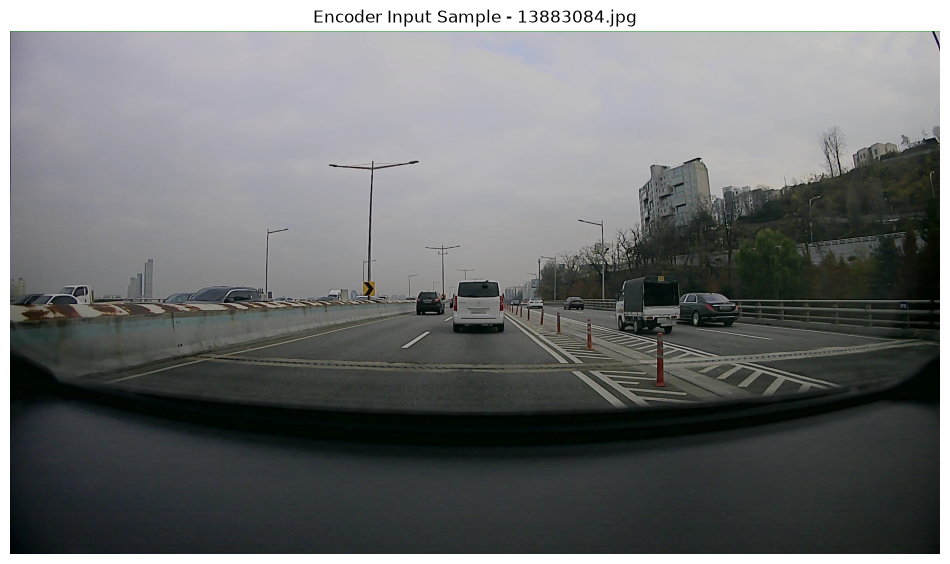

In [5]:
from PIL import Image
import matplotlib.pyplot as plt


# ============================================================
# Final Manifest 첫 번째 이미지 확인
# ============================================================

sample_row = df_image_manifest.iloc[0]

sample_file_name = sample_row["file_name"]
sample_image_path = encoder_image_path_map[sample_file_name]

sample_image = Image.open(
    sample_image_path
).convert("RGB")


print("file_name :", sample_file_name)

print("image path:")
print(sample_image_path)

print()

print("PIL image mode:", sample_image.mode)
print("PIL image size:", sample_image.size)
print("Manifest size :", sample_row["image_size"])


plt.figure(figsize=(12, 7))

plt.imshow(sample_image)

plt.title(
    f"Encoder Input Sample - {sample_file_name}"
)

plt.axis("off")

plt.show()

## 5. ConvNeXt-Tiny Setup

ConvNeXt-Tiny backbone을 사용하기 위해 `timm`을 불러오고 CUDA device를 설정한다.

PyTorch에서는 모델과 입력 Tensor가 같은 device에 있어야 하므로, 현재 GPU가 정상적으로 사용 가능한지 다시 확인한 뒤 `cuda`를 사용한다.


In [6]:
import timm


print("timm version:", timm.__version__)

print(
    "CUDA available:",
    torch.cuda.is_available()
)


assert (
    torch.cuda.is_available()
), (
    "CUDA GPU를 사용할 수 없습니다."
)


device = torch.device("cuda")


print("Device:", device)
print(
    "GPU:",
    torch.cuda.get_device_name(0)
)

c:\accident_ai\Accident_AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


timm version: 1.0.28
CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 3060


## 6. ConvNeXt-Tiny Pretrained Load

ImageNet pretrained weight를 사용하는 ConvNeXt-Tiny를 불러온다.

- `pretrained=True`: ImageNet에서 학습된 weight를 초기값으로 사용
- `features_only=True`: 최종 classification 결과 대신 중간 feature map을 출력
- `out_indices=(0, 1, 2, 3)`: ConvNeXt의 4개 stage 출력을 모두 사용

In [7]:
# ============================================================
# ConvNeXt-Tiny Pretrained Backbone
# ============================================================

encoder_backbone = timm.create_model(
    "convnext_tiny",
    pretrained=True,
    features_only=True,
    out_indices=(0, 1, 2, 3),
)


encoder_backbone = encoder_backbone.to(device)

encoder_backbone.eval()


print("ConvNeXt-Tiny pretrained load 완료!")

ConvNeXt-Tiny pretrained load 완료!


## 7. ConvNeXt Feature Structure Check

ConvNeXt-Tiny가 반환하는 multi-scale feature의 channel 수와 reduction을 확인한다.

Stage가 깊어질수록 feature map의 가로·세로 크기는 작아지고 channel 수는 증가한다.  
이 channel / reduction 구조는 ConvNeXt-Tiny backbone 자체의 구조이며 일반적인 fine-tuning에서 임의로 변경하지 않는다.



In [8]:
# ============================================================
# ConvNeXt-Tiny Multi-scale Feature 정보 확인
# ============================================================

feature_channels = (
    encoder_backbone
    .feature_info
    .channels()
)

feature_reductions = (
    encoder_backbone
    .feature_info
    .reduction()
)


print("Feature channels :", feature_channels)
print("Feature reduction:", feature_reductions)


print()

for index, (
    channels,
    reduction
) in enumerate(
    zip(
        feature_channels,
        feature_reductions
    ),
    start=1
):

    print(
        f"C{index}: "
        f"channels={channels}, "
        f"reduction={reduction}"
    )

Feature channels : [96, 192, 384, 768]
Feature reduction: [4, 8, 16, 32]

C1: channels=96, reduction=4
C2: channels=192, reduction=8
C3: channels=384, reduction=16
C4: channels=768, reduction=32


## 8. Encoder Input Configuration

ConvNeXt-Tiny pretrained 입력 설정과 현재 Model A에서 사용할 이미지 크기를 정의한다.

Pretrained 설정의 `interpolation`, `mean`, `std`는 이후 입력 Transform에 사용한다.  
현재 이미지 내용은 원본과 같은 16:9 비율인 **768 × 432 (W × H)** 로 resize한다.

ConvNeXt의 최대 reduction 32에 맞추기 위해 위·아래에 각각 8 pixel을 padding하여 최종 모델 입력을 **768 × 448**로 만든다.

```text
768 × 432 image
+ Top 8 / Bottom 8 padding
= 768 × 448 model input
```

현재 크기는 Encoder 개발 기준이며, 최종 Multi-task 연결 후 성능과 GPU 사용량을 보며 config에서 조정할 수 있도록 한다.


In [9]:
from torchvision import transforms
from torchvision.transforms import InterpolationMode


# ============================================================
# ConvNeXt-Tiny Pretrained Input Configuration
# ============================================================

data_config = (
    timm.data
    .resolve_model_data_config(
        encoder_backbone
    )
)


print("Pretrained data config:")
print(data_config)

Pretrained data config:
{'input_size': (3, 224, 224), 'interpolation': 'bicubic', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 0.95, 'crop_mode': 'center'}


In [10]:
# ============================================================
# Model A Current Input Configuration
#
# 실제 이미지 영역 : 768 x 432 (W x H)
# Model 입력       : 768 x 448 (W x H)
# Padding          : Top 8 / Bottom 8
# ============================================================

IMAGE_WIDTH = 768
IMAGE_HEIGHT = 432

PAD_LEFT = 0
PAD_TOP = 8
PAD_RIGHT = 0
PAD_BOTTOM = 8

MODEL_WIDTH = (
    IMAGE_WIDTH
    + PAD_LEFT
    + PAD_RIGHT
)

MODEL_HEIGHT = (
    IMAGE_HEIGHT
    + PAD_TOP
    + PAD_BOTTOM
)


print(
    "Image size :",
    f"{IMAGE_WIDTH} x {IMAGE_HEIGHT}"
)

print(
    "Model size :",
    f"{MODEL_WIDTH} x {MODEL_HEIGHT}"
)


assert (
    MODEL_WIDTH % 32 == 0
    and
    MODEL_HEIGHT % 32 == 0
), (
    "Model 입력 크기는 ConvNeXt 최대 "
    "reduction 32에 맞게 설정되어야 합니다."
)

Image size : 768 x 432
Model size : 768 x 448


## 9. Encoder Input Transform

실제 PIL 이미지를 ConvNeXt-Tiny 입력 Tensor로 변환하는 전처리 과정을 정의한다.

```text
PIL RGB Image
    ↓
Resize        : 768 × 432
    ↓
ToTensor      : [3, 432, 768], 0~255 → 0~1
    ↓
Normalize     : pretrained mean / std 적용
    ↓
Padding       : Top 8 / Bottom 8
    ↓
Model Input   : [3, 448, 768]
```

`ToTensor()`는 PIL 이미지를 PyTorch Tensor로 바꾸면서 `HWC → CHW` 변환과 0~1 rescaling을 함께 수행한다.

Padding은 Normalize 이후 적용한다. 이때 `fill=0`은 raw RGB의 검정색을 의미하는 것이 아니라, **Normalize된 입력 공간의 기준값 0으로 padding 영역을 채운다**는 뜻이다.

추후 Segmentation Head와 통합할 때 Resize / Padding은 이미지와 GT mask에 동일하게 적용하고, Normalize는 이미지에만 적용하도록 전체 transform을 다시 구성한다.


In [11]:
# ============================================================
# Model A Encoder Input Transform
# ============================================================

NORMALIZED_PAD_VALUE = 0.0


encoder_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_HEIGHT, IMAGE_WIDTH),
        interpolation=InterpolationMode.BICUBIC
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=data_config["mean"],
        std=data_config["std"]
    ),

    transforms.Pad(
        (
            PAD_LEFT,
            PAD_TOP,
            PAD_RIGHT,
            PAD_BOTTOM
        ),
        fill=NORMALIZED_PAD_VALUE,
        padding_mode="constant"
    ),
])


print("Encoder transform:")
print(encoder_transform)


Encoder transform:
Compose(
    Resize(size=(432, 768), interpolation=bicubic, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
    Pad(padding=(0, 8, 0, 8), fill=0.0, padding_mode=constant)
)


## 10. Encoder Input Transform Check

Final Image Manifest에 포함된 실제 이미지 한 장을 `encoder_transform`에 통과시켜 최종 Encoder 입력 형태를 확인한다.

이번 단계에서는 다음 항목만 확인한다.

- Final Manifest 기준 이미지가 사용되는지
- `768 × 432` resize 후 위·아래 padding이 정상적으로 적용되는지
- 최종 Tensor shape이 `[3, 448, 768]`인지
- Normalize된 Tensor를 다시 시각화했을 때 이미지와 padding 위치가 정상인지

Lane Vector 좌표가 resize / padding 이후에도 실제 차선과 정확히 맞는지는 다음 단계에서 overlay하여 확인한다.


file_name:
13883084.jpg

Original PIL size:
(1920, 1080)

Transformed Tensor shape:
torch.Size([3, 448, 768])
Tensor dtype:
torch.float32
Tensor value range: -2.1179039478302 ~ 1.9254032373428345


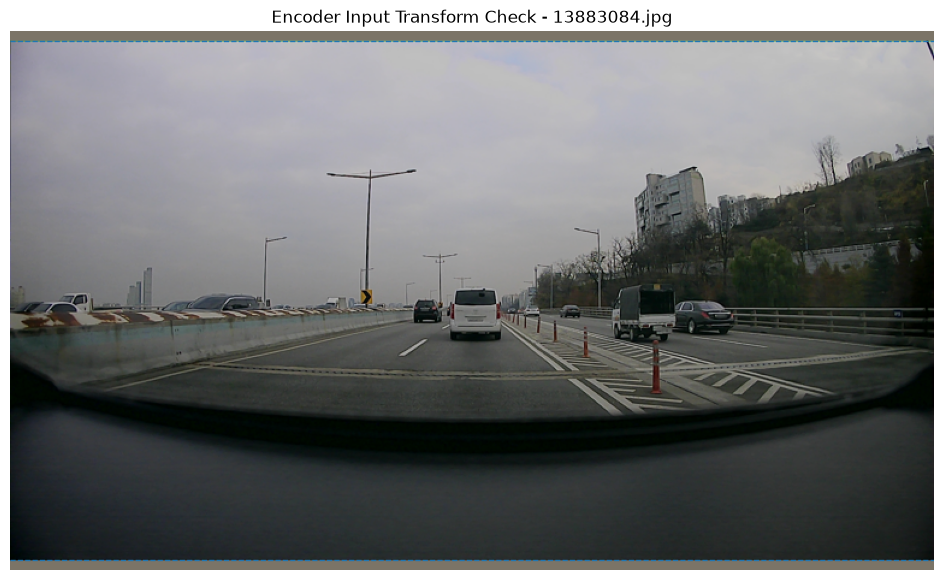


Encoder Input Transform 확인 완료!


In [12]:
# ============================================================
# Final Manifest 실제 이미지 Transform 확인
# ============================================================

sample_file_name = (
    df_lane_vector_ordered["file_name"]
    .iloc[0]
)

sample_image_path = (
    encoder_image_path_map[
        sample_file_name
    ]
)

sample_image = (
    Image.open(sample_image_path)
    .convert("RGB")
)


# ============================================================
# Encoder Transform 적용
# ============================================================

sample_tensor = encoder_transform(
    sample_image
)


print("file_name:")
print(sample_file_name)

print()

print("Original PIL size:")
print(sample_image.size)

print()

print("Transformed Tensor shape:")
print(sample_tensor.shape)

print("Tensor dtype:")
print(sample_tensor.dtype)

print(
    "Tensor value range:",
    float(sample_tensor.min()),
    "~",
    float(sample_tensor.max())
)


assert (
    tuple(sample_tensor.shape)
    ==
    (
        3,
        MODEL_HEIGHT,
        MODEL_WIDTH
    )
), (
    "Encoder 입력 Tensor shape이 "
    "예상 크기와 다릅니다."
)


# ============================================================
# Normalize 역변환 후 시각화
# ============================================================

mean = torch.tensor(
    data_config["mean"],
    dtype=sample_tensor.dtype
).view(3, 1, 1)

std = torch.tensor(
    data_config["std"],
    dtype=sample_tensor.dtype
).view(3, 1, 1)


display_tensor = (
    sample_tensor
    .cpu()
    * std
    + mean
)

display_tensor = (
    display_tensor
    .clamp(0, 1)
    .permute(1, 2, 0)
    .numpy()
)


plt.figure(
    figsize=(12, 7)
)

plt.imshow(
    display_tensor
)

# 실제 이미지 영역과 padding 경계 표시
plt.axhline(
    PAD_TOP,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    PAD_TOP + IMAGE_HEIGHT - 1,
    linestyle="--",
    linewidth=1
)

plt.title(
    f"Encoder Input Transform Check - {sample_file_name}"
)

plt.axis("off")
plt.show()


print()
print("Encoder Input Transform 확인 완료!")


### 10-2. Lane Vector Geometry Check

같은 이미지의 Ordered Lane Vector 좌표를 Encoder 입력 크기에 맞게 변환한 뒤, 실제 차선 위에 정상적으로 겹치는지 확인한다.

원본 이미지 좌표에 resize 비율을 적용하고, y 좌표에는 위쪽 padding만큼 추가한다.

```text
x_new = x_old × scale_x
y_new = y_old × scale_y + PAD_TOP
```

현재 원본과 resize 이미지가 모두 16:9이므로 x / y 축의 scale은 동일하지만, 코드에서는 실제 이미지 크기를 기준으로 각각 계산한다.

이 검증을 통해 이미지 Transform과 Vector annotation의 좌표계가 동일하게 유지되는지 확인한다.


Lane Boundary 수:
8

scale_x: 0.4
scale_y: 0.4


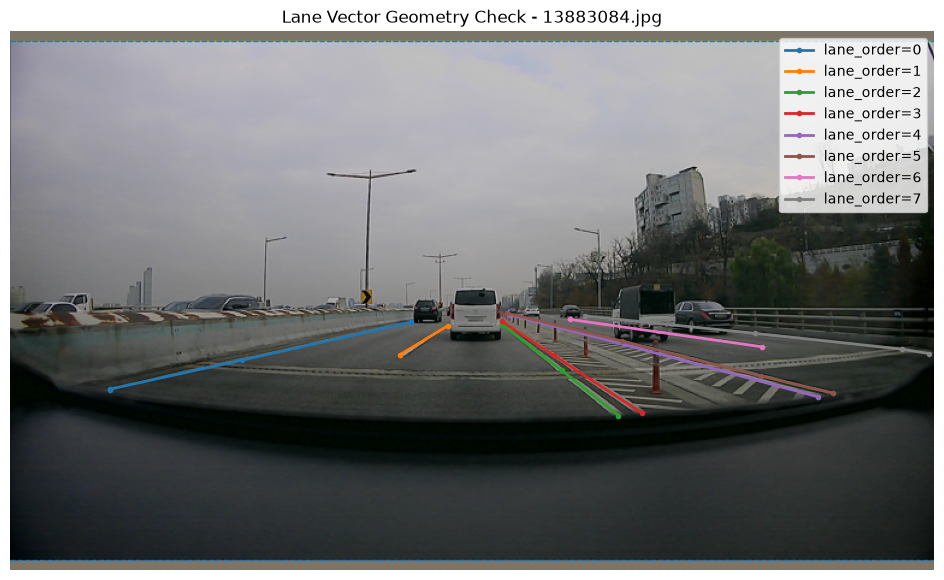


Lane Vector Geometry 확인 완료!


In [13]:
# ============================================================
# Sample Image의 Lane Vector 가져오기
# ============================================================

sample_lane_df = (
    df_lane_vector_ordered[
        df_lane_vector_ordered["file_name"]
        ==
        sample_file_name
    ]
    .sort_values("lane_order")
    .copy()
)


print("Lane Boundary 수:")
print(len(sample_lane_df))


# ============================================================
# 원본 → Encoder 입력 좌표 변환 비율
# ============================================================

original_width, original_height = (
    sample_image.size
)

scale_x = (
    IMAGE_WIDTH
    /
    original_width
)

scale_y = (
    IMAGE_HEIGHT
    /
    original_height
)


print()
print("scale_x:", scale_x)
print("scale_y:", scale_y)


# ============================================================
# Transform 결과 이미지 위에 Lane Vector Overlay
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 7)
)

ax.imshow(
    display_tensor
)


for row in sample_lane_df.itertuples(
    index=False
):

    transformed_x = [
        x * scale_x
        for x in row.x_data
    ]

    transformed_y = [
        y * scale_y + PAD_TOP
        for y in row.y_data
    ]

    ax.plot(
        transformed_x,
        transformed_y,
        marker="o",
        markersize=3,
        linewidth=2,
        label=f"lane_order={int(row.lane_order)}"
    )


# 실제 이미지 영역과 padding 경계
ax.axhline(
    PAD_TOP,
    linestyle="--",
    linewidth=1
)

ax.axhline(
    PAD_TOP + IMAGE_HEIGHT - 1,
    linestyle="--",
    linewidth=1
)


ax.set_title(
    f"Lane Vector Geometry Check - {sample_file_name}"
)

ax.legend()
ax.axis("off")

plt.show()


print()
print(
    "Lane Vector Geometry 확인 완료!"
)


## 11. ModelAEncoder Wrapper

검증이 끝난 ConvNeXt-Tiny backbone을 Model A에서 재사용할 수 있도록 `ModelAEncoder` 클래스로 구성한다.

Encoder는 전처리가 완료된 `[B, 3, H, W]` Tensor를 입력받아 ConvNeXt-Tiny의 multi-scale feature `C1 ~ C4`를 반환한다.

Resize, Normalize, Padding 등의 입력 전처리는 Encoder 내부에 포함하지 않고 `encoder_transform`에서 별도로 관리한다.

In [14]:
import torch.nn as nn


# ============================================================
# Model A Shared Encoder
# ============================================================

class ModelAEncoder(nn.Module):

    def __init__(
        self,
        backbone_name="convnext_tiny",
        pretrained=True
    ):
        super().__init__()

        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            features_only=True,
            out_indices=(0, 1, 2, 3)
        )

        self.feature_channels = (
            self.backbone
            .feature_info
            .channels()
        )

        self.feature_reductions = (
            self.backbone
            .feature_info
            .reduction()
        )


    def forward(self, x):

        features = self.backbone(x)

        c1, c2, c3, c4 = features

        return {
            "c1": c1,
            "c2": c2,
            "c3": c3,
            "c4": c4
        }

### 11-1. ModelAEncoder Forward Check

앞에서 검증한 실제 이미지 Tensor를 `ModelAEncoder`에 입력하여 Wrapper가 C1~C4 feature를 정상적으로 반환하는지 확인한다.

현재 모델 입력은 `[1, 3, 448, 768]`이며, 각 feature의 shape이 ConvNeXt-Tiny의 channel / reduction 구조와 일치하는지 확인한다.

In [15]:
# ============================================================
# ModelAEncoder 생성
# ============================================================

encoder = ModelAEncoder(
    backbone_name="convnext_tiny",
    pretrained=True
).to(device)

encoder.eval()


print("Feature channels:")
print(encoder.feature_channels)

print()

print("Feature reductions:")
print(encoder.feature_reductions)

Feature channels:
[96, 192, 384, 768]

Feature reductions:
[4, 8, 16, 32]


In [16]:
# ============================================================
# 실제 이미지 Batch 구성
# ============================================================

sample_batch = (
    sample_tensor
    .unsqueeze(0)
    .to(device)
)


print("Input shape:")
print(sample_batch.shape)


# ============================================================
# ModelAEncoder Forward
# ============================================================

with torch.inference_mode():

    encoder_features = encoder(
        sample_batch
    )


print()

for feature_name, feature in encoder_features.items():

    print(
        f"{feature_name}:",
        feature.shape
    )

Input shape:
torch.Size([1, 3, 448, 768])

c1: torch.Size([1, 96, 112, 192])
c2: torch.Size([1, 192, 56, 96])
c3: torch.Size([1, 384, 28, 48])
c4: torch.Size([1, 768, 14, 24])


## 12. Encoder Freeze / Unfreeze

Fine-tuning 실험에서 Encoder의 학습 범위를 조절할 수 있도록 freeze / unfreeze 기능을 구성한다.

먼저 현재 `timm` ConvNeXt-Tiny backbone의 실제 module 구조를 확인한 뒤, 전체 Encoder와 각 stage의 `requires_grad`를 제어할 수 있도록 확장한다.

In [17]:
# ============================================================
# ConvNeXt-Tiny Backbone Module 구조 확인
# ============================================================

for name, module in encoder.backbone.named_children():

    print(
        name,
        "->",
        type(module).__name__
    )

stem_0 -> Conv2d
stem_1 -> LayerNorm2d
stages_0 -> ConvNeXtStage
stages_1 -> ConvNeXtStage
stages_2 -> ConvNeXtStage
stages_3 -> ConvNeXtStage


In [18]:
# ============================================================
# Backbone Parameter 이름 일부 확인
# ============================================================

for index, (name, parameter) in enumerate(
    encoder.backbone.named_parameters()
):

    print(
        name,
        "|",
        tuple(parameter.shape)
    )

    if index >= 30:
        break

stem_0.weight | (96, 3, 4, 4)
stem_0.bias | (96,)
stem_1.weight | (96,)
stem_1.bias | (96,)
stages_0.blocks.0.gamma | (96,)
stages_0.blocks.0.conv_dw.weight | (96, 1, 7, 7)
stages_0.blocks.0.conv_dw.bias | (96,)
stages_0.blocks.0.norm.weight | (96,)
stages_0.blocks.0.norm.bias | (96,)
stages_0.blocks.0.mlp.fc1.weight | (384, 96)
stages_0.blocks.0.mlp.fc1.bias | (384,)
stages_0.blocks.0.mlp.fc2.weight | (96, 384)
stages_0.blocks.0.mlp.fc2.bias | (96,)
stages_0.blocks.1.gamma | (96,)
stages_0.blocks.1.conv_dw.weight | (96, 1, 7, 7)
stages_0.blocks.1.conv_dw.bias | (96,)
stages_0.blocks.1.norm.weight | (96,)
stages_0.blocks.1.norm.bias | (96,)
stages_0.blocks.1.mlp.fc1.weight | (384, 96)
stages_0.blocks.1.mlp.fc1.bias | (384,)
stages_0.blocks.1.mlp.fc2.weight | (96, 384)
stages_0.blocks.1.mlp.fc2.bias | (96,)
stages_0.blocks.2.gamma | (96,)
stages_0.blocks.2.conv_dw.weight | (96, 1, 7, 7)
stages_0.blocks.2.conv_dw.bias | (96,)
stages_0.blocks.2.norm.weight | (96,)
stages_0.blocks.2.norm.b

### 12-1. Encoder Freeze / Unfreeze API

확인된 ConvNeXt-Tiny module 구조를 기준으로 Encoder 전체 또는 각 feature stage의 학습 여부를 제어할 수 있도록 `ModelAEncoder`를 확장한다.

`C1`은 stem과 `stages_0`, 이후 `C2~C4`는 각각 `stages_1~3`과 대응하도록 관리한다.

In [20]:
# ============================================================
# Model A Shared Encoder
# ============================================================

class ModelAEncoder(nn.Module):

    def __init__(
        self,
        backbone_name="convnext_tiny",
        pretrained=True
    ):
        super().__init__()

        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            features_only=True,
            out_indices=(0, 1, 2, 3)
        )

        self.feature_channels = (
            self.backbone
            .feature_info
            .channels()
        )

        self.feature_reductions = (
            self.backbone
            .feature_info
            .reduction()
        )


    # ========================================================
    # Forward
    # ========================================================

    def forward(self, x):

        features = self.backbone(x)

        c1, c2, c3, c4 = features

        return {
            "c1": c1,
            "c2": c2,
            "c3": c3,
            "c4": c4
        }


    # ========================================================
    # 전체 Encoder Freeze
    # ========================================================

    def freeze_encoder(self):

        for parameter in self.backbone.parameters():
            parameter.requires_grad = False


    # ========================================================
    # 전체 Encoder Unfreeze
    # ========================================================

    def unfreeze_encoder(self):

        for parameter in self.backbone.parameters():
            parameter.requires_grad = True


    # ========================================================
    # Stage별 학습 범위 설정
    # ========================================================

    def set_trainable_stages(
        self,
        trainable_stages
    ):

        valid_stages = {
            "c1",
            "c2",
            "c3",
            "c4"
        }

        trainable_stages = set(
            trainable_stages
        )

        invalid_stages = (
            trainable_stages
            -
            valid_stages
        )

        if invalid_stages:

            raise ValueError(
                f"Unknown stages: {invalid_stages}"
            )


        # 먼저 전체 Freeze
        self.freeze_encoder()


        # C1
        # stem + stages_0
        if "c1" in trainable_stages:

            for parameter in (
                self.backbone
                .stem_0
                .parameters()
            ):
                parameter.requires_grad = True

            for parameter in (
                self.backbone
                .stem_1
                .parameters()
            ):
                parameter.requires_grad = True

            for parameter in (
                self.backbone
                .stages_0
                .parameters()
            ):
                parameter.requires_grad = True


        # C2
        if "c2" in trainable_stages:

            for parameter in (
                self.backbone
                .stages_1
                .parameters()
            ):
                parameter.requires_grad = True


        # C3
        if "c3" in trainable_stages:

            for parameter in (
                self.backbone
                .stages_2
                .parameters()
            ):
                parameter.requires_grad = True


        # C4
        if "c4" in trainable_stages:

            for parameter in (
                self.backbone
                .stages_3
                .parameters()
            ):
                parameter.requires_grad = True

In [21]:
encoder = ModelAEncoder(
    backbone_name="convnext_tiny",
    pretrained=True
).to(device)

In [22]:
encoder.set_trainable_stages(
    ["c3", "c4"]
)

In [23]:
# ============================================================
# Freeze / Unfreeze 상태 확인
# ============================================================

module_names = [
    "stem_0",
    "stem_1",
    "stages_0",
    "stages_1",
    "stages_2",
    "stages_3"
]


for module_name in module_names:

    module = getattr(
        encoder.backbone,
        module_name
    )

    trainable_count = sum(
        parameter.numel()
        for parameter in module.parameters()
        if parameter.requires_grad
    )

    total_count = sum(
        parameter.numel()
        for parameter in module.parameters()
    )

    print(
        f"{module_name:10s} | "
        f"trainable: {trainable_count:,} / "
        f"total: {total_count:,}"
    )

stem_0     | trainable: 0 / total: 4,704
stem_1     | trainable: 0 / total: 192
stages_0   | trainable: 0 / total: 237,888
stages_1   | trainable: 0 / total: 992,256
stages_2   | trainable: 11,112,960 / total: 11,112,960
stages_3   | trainable: 15,470,592 / total: 15,470,592
